In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="6" color="red">ch10. N차원 배열 다루기</font>
- N차원 배열 객체 : 동일 자료형의 집합
- 2차원 배열은 행렬개념으로 이해
- [numpy](https://numpy.org)
- [numpt API Docs](https://numpy.org/doc/stable/reference/index.html)
# 넘파이 패키지

In [4]:
import numpy as np
np.__version__ # tensorflow==2.10과 맞는 numpy 버전

'1.23.5'

In [6]:
# np.arange(from,stop, by) : from부터 stop앞까지 by씩 증가하는 1차원 정수배열
a = np.arange(15)
print(a.shape) # 15열짜리 1차원 배열을 만들었당께요
a

(15,)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

## 배열 속성

In [15]:
from numpy import arange
a = arange(15,
           #dtype=np.int8)
          ).reshape(3, 5) #3행5열짜리로 변환
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [12]:
type(a) # a변수의 타입

numpy.ndarray

In [13]:
a.dtype # a배열의 요소(item)들의 type

dtype('int8')

In [16]:
a.dtype.name

'int32'

In [17]:
a.itemsize # 한 요소(item)의 bytesize

4

In [18]:
a.ndim # 축수(차원수)

2

In [20]:
a.size # q배열 요소의 갯수

15

In [19]:
a.shape # 배열 구조(1차원 15열)

(3, 5)

In [21]:
print("shape 조정전 a:\n", a)
a.shape = (5, 3)
print("shape 조정후 a:\n", a)

shape 조정전 a:
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]
shape 조정후 a:
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]]


## 배열 타입 변경

In [22]:
# 배열 요소의 타입변경을 이렇게 하면 안됨
a = np.arange(12).reshape(3, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [23]:
a.size # 요소갯수

12

In [24]:
a.dtype

dtype('int32')

In [25]:
a.itemsize

4

In [26]:
a.dtype = np.int64
a.dtype

dtype('int64')

In [29]:
a.itemsize  # 요소의 byte수

8

In [28]:
a

array([[ 4294967296, 12884901890],
       [21474836484, 30064771078],
       [38654705672, 47244640266]], dtype=int64)

In [30]:
a.size # 요소수

6

In [31]:
# 배열 요소의 타입 변경 하는 방법
a = arange(15).reshape(5, 3)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [37]:
# a의 타입을 변경해라~ # 출력할 경우 a가 바뀌지않음. 출력이 안될 경우
a= a.astype(np.int64)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [38]:
# a.astype(np.int64) 출력O->a가 바뀌지 않음. 출력X->a 바뀜
a= a.astype(np.int64)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [39]:
a.dtype

dtype('int64')

In [40]:
a.itemsize

8

In [41]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [43]:
a.ravel() # flaten된 배열을 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

In [104]:
a.flatten() # # flaten된 배열을 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

## 배열 저장
- pkl(객체저장, 배열, 머신러닝 모델 저장) vs npy(넘파이 전용포맷, io개선

In [51]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [49]:
%%time
import time
start = time.time() # 1970.1.1부터 지금까지의 초수
with open("data/ch10_pkl", "wb") as f:
    pickle.dump(a, f)
end = time.time()
print("실행 시간 :",(end-start))

실행 시간 : 0.0010006427764892578
CPU times: total: 0 ns
Wall time: 2.41 ms


In [46]:
%%time
with open("data/ch10_pkl", "rb") as f:
    loaded_a = pickle.load(f)

CPU times: total: 0 ns
Wall time: 45.9 ms


In [50]:
# a==(파일저장)==> 피클파일 ==(load)==> loaded_a
loaded_a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [52]:
%%time
np.save("data/ch11.npy", a) # 넘파이전용포맷. 빠르고 효율적이고 안전하게 저장

CPU times: total: 0 ns
Wall time: 2.07 ms


In [55]:
%%time
loaded_a2 = np.load("data/ch11.npy")

CPU times: total: 0 ns
Wall time: 1.98 ms


In [56]:
# a ==(저장)==> npy(248B) ==(load)==> loaded_a2
loaded_a2

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

# 넘파이배열
- array()함수를 이용한 다른 파이썬 데이터구조(list, tup)를 배열변환
- 기타 함수 : arange, ones, zeros, full, empty ...
- 랜덤값을 갖는 배열 생성함수 ...
- [넘파이함수들](https://numpy.org/doc/stable/reference/index.html)
## array()함수로 넘파이 배열 만들기
- array(obj, dtype=np.type, copy=T/F)
- array(obj, dtype='type', copy=T/F) type 예 : int16, int32, float16, float32, flost64,...

In [57]:
a = np.array([2, 14, 6],
            # dtype=np.int16

            ) # 정수의 기본 타입은 int32 / 실수의기본타입은 float64 
a, a.dtype

(array([ 2, 14,  6]), dtype('int32'))

In [58]:
a[0], a[1], a[2]

(2, 14, 6)

In [59]:
for item in a:
    print(item, end="\t")

2	14	6	

In [60]:
b = np.array([[1.5, 2.3], # 동일자료형의 집합으로 배열생성 : 정수>실수>문자
             [4, 5]])     # 실수 배열의 기본타입 : float64
b

array([[1.5, 2.3],
       [4. , 5. ]])

In [61]:
b.dtype

dtype('float64')

In [62]:
l = [[1.5, 2.3], [4, 5]]
l[0][1]

2.3

In [64]:
b[0, 1] # 2차원 [axis0=행, axis1=열] cf. 1차원[axis0=열]

2.3

In [105]:
a = np.array([[1.5, 2.3], 
              [4,5]], 
            # dtype="float32"
             dtype=np.float32
            ).reshape(4)
a

array([1.5, 2.3, 4. , 5. ], dtype=float32)

In [66]:
a.dtype

dtype('float32')

In [106]:
# a의 배열 구조 변경
a.shape = (2,2)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

In [68]:
# a의 dtype(요소의 타입) 변경
# a.dtype = np.float16
a = a.astype(np.float16)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float16)

In [69]:
l = [[1.5, 2.3],
     [4, 5]]
for row in l:
    for item in row:
        print(item, end=" ")
    print()

1.5 2.3 
4 5 


In [70]:
for i, row in enumerate(l):
    for j, item in enumerate(row):
        print(f"{i}행{j}열 : {l[i][j]}", end="\t")
    print()

0행0열 : 1.5	0행1열 : 2.3	
1행0열 : 4	1행1열 : 5	


In [71]:
for row in a:
    for item in row:
        print(item, end=" ")
    print()

1.5 2.3 
4.0 5.0 


In [73]:
for i, row in enumerate(a):
    for j, item in enumerate(row):
        #print(f"{i}행{j}열 : {a[i][j]}", end="\t")
        print(f"{i}행{j}열 : {a[i, j]}", end="\t") # float16은 소숫점이하가 불안정
    print()

0행0열 : 1.5	0행1열 : 2.30078125	
1행0열 : 4.0	1행1열 : 5.0	


In [74]:
print(b[0,0]) # 인덱싱
#print(b[0,2]) 없는 인덱싱은 에러

1.5


In [75]:
# 슬라이싱 from:stop:by : from부터 stop전까지 by씩 전진. 인덱싱은 음수
b[0:, 1:10] # 0~끝행, 1열부터 10전열까지 슬라싱(행과 열 모두 슬라이싱 2차원 배열)

array([2.3, 5. ])

In [76]:
b[0, 1:3] # 0행, 1열부터 3열전까지 슬라이싱(열만 슬라이싱 1차원 배열)

array([2.3])

In [86]:
b = np.array([[1, 2, 3],
             [6, 7, 8]])
# 모든 행의 마지막 열만 추출
b[:, -1:]

array([[3],
       [8]])

In [89]:
# 모든 행의 마지막 열을 제외한 부분 추출
b[:, 0:2]

array([[1, 2],
       [6, 7]])

In [91]:
# 스칼라 변수
a = 10 #원본
b = a # 복제본
print(f"a={a}, b={b}, a주소={id(a)}, b주소={id(b)}")
b = -1
print(f"a={a}, b={b}, a주소={id(a)}, b주소={id(b)}")

a=10, b=10, a주소=2076931981840, b주소=2076931981840
a=10, b=-1, a주소=2076931981840, b주소=2076931981488


In [98]:
# numpy 배열
c = np.array([[1, 2],[3, 4]], dtype=np.uint8) #원본
#d = np.array(c, copy=False) # d = c와 동일 # 할당
d = np.array(c, copy=True) # d = c.copy와 동일 # 깊은 복사
#d = c.copy() #할당
print("c=", c, sep="\n")
print("d=", c, sep="\n")
print("두 변수의 주소 :", id(c), id(d))
d[0, 0] = 9
print("c=", c, sep="\n")
print("d=", c, sep="\n")
print("두 변수의 주소 :", id(c), id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소 : 2077078984560 2077061854864
c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소 : 2077078984560 2077061854864


In [107]:
# numpy 배열
c = np.array([[1, 2], [3, 4]], dtype=np.int8) # 원본
d = np.array(c, copy=True) # d = c.copy()와 동일 #깊은 복사
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0,0] = 9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소 : 2077080074064 2077080073776
c=
[[1 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 2077080074064 2077080073776


In [108]:
# copy=False해도 깊은 복사가 되는 경우 : dtype이 바뀌면 자동 깊은 복사
c = np.array([[1, 2], [3, 4]], dtype=np.int8) # 원본
d = np.array(c, copy=False,    dtype=np.int32)
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0,0] = 9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소 : 2077080073680 2077080074064
c=
[[1 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 2077080073680 2077080074064


## 기본값이 있는 배열 만들기
- np.zeros( tup, [,dtype] ): 요소들이 다 0.0
- np.ones( tup, [,dtype] ) : 요소들이 다 1.0
- np.full(tup, 기본값) : 요소들이 다 두번째 매개변수인 기본값
- np.empty( tup ) : 초기 내용은 임의의 값인 배열(메모리상태에 따라 달라짐)

※ 위의 함수를 이용해서 생성된 배열은 기본 dtype이 float64. dtype속성을 따로 지정 가능

In [163]:
np.ones( (3, 5) ) # 3행5열짜리 2차원 float64 배열(요소들은 다 0)
np.ones( (5,) ) # 5열짜리 1차원 float64 배열(요소들은 다 0)
np.ones( 5 ) # 5열짜리 1차원 float64 배열(요소들은 다 0)

array([1., 1., 1., 1., 1.])

In [165]:
X = np.ones( (2, 5), dtype=np.bool8)
print(X)
print(X.dtype)
print(X.itemsize)

[[ True  True  True  True  True]
 [ True  True  True  True  True]]
bool
1


In [161]:
x = np.full( (2,5), 255 )
print(x)
print(x.dtype)

[[255 255 255 255 255]
 [255 255 255 255 255]]
int32


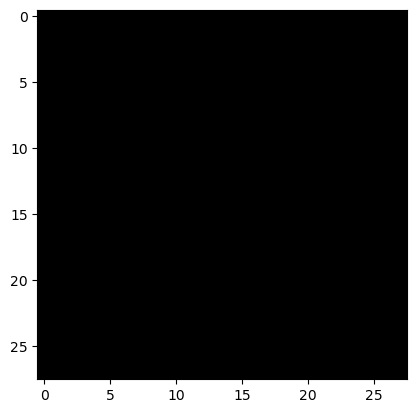

In [176]:
import matplotlib.pyplot as plt
img = np.full( (28,28), 255, dtype=np.uint8) # 하얀색
img = np.full( (28,28), 200, dtype=np.uint8) # 회색
img = np.zeros( (28,28), dtype=np.uint8) # 검은색
# plt.figure(figsize=(1,1))
plt.imshow(img, cmap="gray", vmin=0, vmax=255 )
#plt.axis("off")
plt.show()

In [177]:
np.empty( (3, 2) )

array([[0.37472222, 0.33722222],
       [0.37472222, 4.03322222],
       [4.07072222, 0.33722222]])

## 랜덤값을 갖는 배열 만들기
- n차원 배열
- np.random.random( tup ) : 0부터 1미만의 균등분포를 갖는 tup 사이즈 랜덤값
- np.random.uniform(low=0, high=1.0, size=tup) : low부터 high미만까지 균등분포를 갖는 랜덤값
- np.random.normal(loc=0.0, scale=1.0, size=tup) : 평균loc, 표준편차scale을 갖는 정규분포 랜덤값

- 1차원 배열
- np.random.rand(n) : 균등분포의 1차원 0~1미만 난수 배열 발생(난수가 n개)
- np.random.randn(n0 : 표준정규분포(평균0, 표준편차가 1인 정규분포)의 1차원 난수 배열 발생(난수 n개

- np.random.randint(n) : 0부터 n미만의 정수 난수 1개발생 == random.randint(0, n+1)
- np.random.randint(from, to) : from부터 to미만의 정수 난수 1개발생 == random.randint(0, to-1)

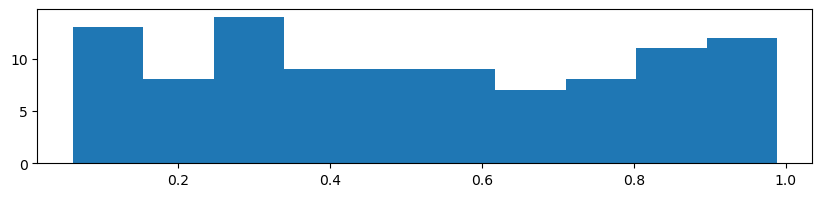

In [190]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
x = np.random.random(100)
plt.hist(x, bins=10)
plt.show()

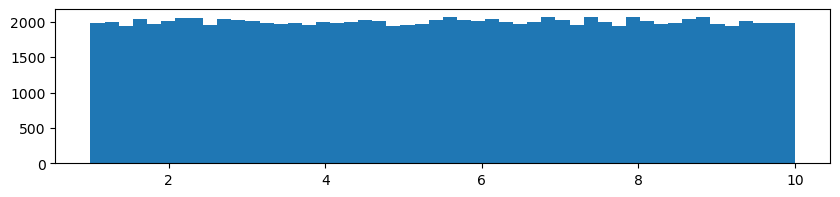

In [195]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
#x = np.random.random(10000)
x = np.random.uniform(1,10, 100000)
plt.hist(x, bins=50)
plt.show()

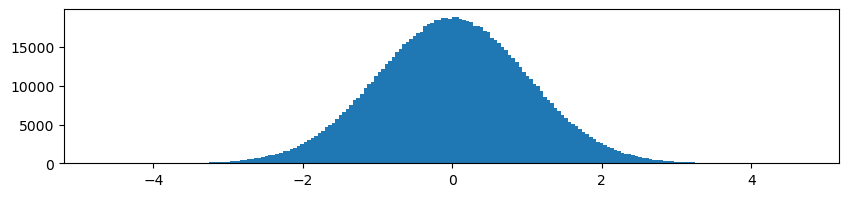

In [205]:
plt.figure(figsize=(10, 2))
x = np.random.normal(50, 10, 1000000) # 정규분포
x = np.random.normal(0, 1, 1000000) # 표준 정규분포
x = np.random.randn(1000000) # 표준분포
plt.hist(x, bins=200)
plt.show()

In [3]:
# 2차원 균등분포 난수(0~1미만 실수 난수) 배열
import numpy as np
# np.random.seed(3) seed값을 밪추면 발생되는 난수가 동일. seed값을 초기화하려면 커널 재시작
np.random.random( (2, 5) ) # 2행5열 2차원 난수배열

array([[0.69886568, 0.09400751, 0.04309904, 0.42725119, 0.20772436],
       [0.78100635, 0.02828368, 0.14677678, 0.5852144 , 0.22761587]])

In [4]:
# 2차원 균등분포 난수(-1~1미만의 실수 난수) 배열
np.random.uniform(10, 1, (2, 5)) # 2행5열짜리 -1~ 1미만의 2차원 난수배열

array([[9.00032924, 1.50407159, 9.56440429, 8.6932739 , 7.34466124],
       [6.58827143, 7.90179909, 6.2616931 , 3.80370601, 8.15213786]])

In [5]:
# 2차원 정규분포 난수(평균과 표준편차로 생성된 난수) 배열
x = np.random.normal(3, 1, size=(2,5)) # 2행5열의 평균 3에 표준편차 1인 2차원 난수
x

array([[4.43249211, 2.31056876, 0.97785026, 5.48744477, 3.33545388],
       [2.78925315, 3.19226195, 4.40471233, 2.03132129, 1.94539357]])

In [6]:
x[0,1]

2.310568761120365

In [7]:
# 1차원 균동분포 난수배열
np.random.rand(3)
# rand는 1차원밖에못만듬
np.random.random(3)
# random은 1차원, 2차원, 3차원 ... 다 가능하다

array([0.84785166, 0.50746872, 0.51716601])

In [8]:
# 1차원 표준정규분포(평균 0, 표준편차1인 정규분포) 배열
np.random.randn(3)
np.random.normal(size=3)

array([-0.67123641, -0.97040749, -1.33302392])

## 연속된 값을 갖는 배열 만들기
- np.arange(from, to , by, dtype) : from부터 to(to미포함)앞까지 by씩 건너뛴 값을1차원 배열로 생성 
- np.linspace(from, to , num) : from부터 to(to포함)까지 num개 숫자들을 1차원 배열로 생성

In [9]:
np.arange(10, 30, 5, dtype=np.float32)

array([10., 15., 20., 25.], dtype=float32)

In [10]:
np.arange(0, 2.7, 0.3)

array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7])

In [11]:
np.linspace(0, 3, 20) # 0부터 3까지 같은 간격으로 20개 수를 배열

array([0.        , 0.15789474, 0.31578947, 0.47368421, 0.63157895,
       0.78947368, 0.94736842, 1.10526316, 1.26315789, 1.42105263,
       1.57894737, 1.73684211, 1.89473684, 2.05263158, 2.21052632,
       2.36842105, 2.52631579, 2.68421053, 2.84210526, 3.        ])

In [12]:
np.linspace(0, 3, 20).reshape(4, 5) # 2차원으로 만들기

array([[0.        , 0.15789474, 0.31578947, 0.47368421, 0.63157895],
       [0.78947368, 0.94736842, 1.10526316, 1.26315789, 1.42105263],
       [1.57894737, 1.73684211, 1.89473684, 2.05263158, 2.21052632],
       [2.36842105, 2.52631579, 2.68421053, 2.84210526, 3.        ]])

In [13]:
x = np.array([0, 1, 2, 3, 4, 5, 6])
# linspace : 특정 구간에 많은 수의 점을 생성할때 유용
x = np.linspace(0, 6, 200)
y = np.sin(x)

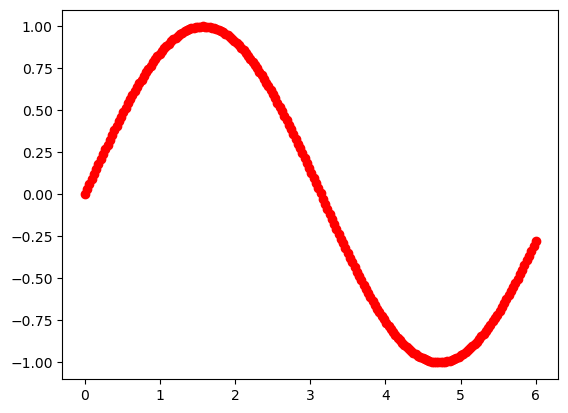

In [14]:
#import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
plt.scatter(x, y, c="r") # 빨간색 점그래프
plt.plot(x, y, c="r") #선그래프 
plt.show()

## 배열의 차원변경
- reshape(행수, 열수) : -1 가능 , 차원 변경된 배열 return
- resize( (행수, 열수) ) " -1불가, 배열을 차원 변경
- revel(), flatten() : 1차원으로 변경된 배열 return
- T : 전치행렬로 변환된 배열을 return
- transpose() : 전치행렬로 변환된 배열을 return

※ 실행결과가 출력되면 배열이 수정되지않고, 실행결과가 없으면 배열이 수정됨

In [15]:
t = np.random.random((2,5))
t

array([[0.74668852, 0.86799727, 0.71014175, 0.13907133, 0.47487124],
       [0.77121124, 0.17998895, 0.03865699, 0.55908976, 0.64023324]])

In [16]:
# t * 10 요소별 연산
# round(t*10) : 스칼라 값을 반올림할때 사용 t*10은 배열이라 실행하면 오류가 생긴다
a = np.round(t*10)
a

array([[7., 9., 7., 1., 5.],
       [8., 2., 0., 6., 6.]])

In [17]:
a = a.astype(np.int16) #astype()을 이용한 요소별 타입 변환
a #2행5열

array([[7, 9, 7, 1, 5],
       [8, 2, 0, 6, 6]], dtype=int16)

In [18]:
a.reshape(5,2)

array([[7, 9],
       [7, 1],
       [5, 8],
       [2, 0],
       [6, 6]], dtype=int16)

In [19]:
a.reshape(5, -1) # -1이 주어지면 해당 차원의 크기가 자동 계산. a의 item이 10니 5행으로 하면 2열로 자동계산

array([[7, 9],
       [7, 1],
       [5, 8],
       [2, 0],
       [6, 6]], dtype=int16)

In [20]:
a.reshape(-1)

array([7, 9, 7, 1, 5, 8, 2, 0, 6, 6], dtype=int16)

In [21]:
a.reshape(2, 5)

array([[7, 9, 7, 1, 5],
       [8, 2, 0, 6, 6]], dtype=int16)

In [22]:
a.resize((2,5)) # a를 바꿈
a.resize(2, 5)
a

array([[7, 9, 7, 1, 5],
       [8, 2, 0, 6, 6]], dtype=int16)

In [23]:
# a.resize(-1) # resize함수에는 -1불가

In [24]:
a.ravel()

array([7, 9, 7, 1, 5, 8, 2, 0, 6, 6], dtype=int16)

In [25]:
a.flatten()

array([7, 9, 7, 1, 5, 8, 2, 0, 6, 6], dtype=int16)

In [26]:
a

array([[7, 9, 7, 1, 5],
       [8, 2, 0, 6, 6]], dtype=int16)

In [27]:
a.T # a의 전치행렬(행과 열을 뒤바꾼 행렬 ex.0행1열->1행0열)

array([[7, 8],
       [9, 2],
       [7, 0],
       [1, 6],
       [5, 6]], dtype=int16)

In [28]:
a.transpose() # a의 전치행렬

array([[7, 8],
       [9, 2],
       [7, 0],
       [1, 6],
       [5, 6]], dtype=int16)

In [29]:
a

array([[7, 9, 7, 1, 5],
       [8, 2, 0, 6, 6]], dtype=int16)

## 배열인쇄

In [30]:
print(np.arange(1001)) # item 갯수가  1000개까지만 나옴

[   0    1    2 ...  998  999 1000]


In [31]:
np.arange(10000).reshape(100,100)

array([[   0,    1,    2, ...,   97,   98,   99],
       [ 100,  101,  102, ...,  197,  198,  199],
       [ 200,  201,  202, ...,  297,  298,  299],
       ...,
       [9700, 9701, 9702, ..., 9797, 9798, 9799],
       [9800, 9801, 9802, ..., 9897, 9898, 9899],
       [9900, 9901, 9902, ..., 9997, 9998, 9999]])

In [32]:
np.get_printoptions()["threshold"] #출력되는 limit

1000

In [33]:
# 배열이 너무 커서 인쇄할 수 없는 경우 자동으로 건너뛰고 모서리 부분만 출력
# 넘퍼아의 인쇄 옵션 변경(인쇄할 사이즈를 조정)
np.set_printoptions(threshold=10000) # 배열 10000개까지 출력하도록 옵션 셋팅
np.set_printoptions(threshold=np.inf) #np.inf:무한대
import sys
np.set_printoptions(threshold=sys.maxsize)

In [96]:
sys.maxsize

9223372036854775807

In [34]:
# 커널을 재시작하거나
import numpy as np
np.set_printoptions(threshold=1000)
np.arange(10000).reshape(100,100)

array([[   0,    1,    2, ...,   97,   98,   99],
       [ 100,  101,  102, ...,  197,  198,  199],
       [ 200,  201,  202, ...,  297,  298,  299],
       ...,
       [9700, 9701, 9702, ..., 9797, 9798, 9799],
       [9800, 9801, 9802, ..., 9897, 9898, 9899],
       [9900, 9901, 9902, ..., 9997, 9998, 9999]])

## 기본 연산 동작
### 배열의 요소별 연산

In [40]:
a = np.array([10, 20, 30, 40], dtype=np.int8)
b = np.arange(4)
print(a) # 배열을 print에 넣으면 array와 ,(콤마)가 안나옴
print(b)
print([1, 2, 3])
print(a.dtype, b.dtype)

[10 20 30 40]
[0 1 2 3]
[1, 2, 3]
int8 int32


In [43]:
c = a+b # 요소별 +연산 (dtype은 큰거로, 정수와 실수연산은 실수로)
print(c)
print(c.dtype)

[10 21 32 43]
int32


In [44]:
a * 2

array([20, 40, 60, 80], dtype=int8)

In [45]:
a * b

array([  0,  20,  60, 120])

In [46]:
a ** b

array([    1,    20,   900, 64000], dtype=int32)

In [47]:
a < 40

array([ True,  True,  True, False])

In [50]:
print(a[ [0,1,2,3] ]) # index를 list로
print(a[ [True,  False,  True, False] ]) # boolean index
print(a[ [0, 2] ])

[10 20 30 40]
[10 30]
[10 30]


In [51]:
# a배열에서 40미만인 데이터만 추출하려면 boolean index 사용
a[a<40]

array([10, 20, 30], dtype=int8)

In [52]:
np.where( [ 10, 40] )

(array([0, 1], dtype=int64),)

### 행렬의 곱(@, dot함수) cf.*(요소별 곱)
- 2차원 배열은 행렬로 취급
- pdf 18p

In [56]:
A = np.array([[1, 1],
             [0, 1]])
B = np.array([[2,0],
              [3,4]])
A, B

(array([[1, 1],
        [0, 1]]),
 array([[2, 0],
        [3, 4]]))

In [59]:
print("요소별 곱 A*B =", A*B, sep="\n")
print("행렬 곱 A@B =", A@B, sep="\n")
print("행렬곱 A.dot(B) =", A.dot(B), sep="\n")

요소별 곱 A*B =
[[2 0]
 [0 4]]
행렬 곱 A@B =
[[5 4]
 [3 4]]
행렬곱 A.dot(B) =
[[5 4]
 [3 4]]


In [70]:
# pdf 19p
# 1번
A = np.array([[-1,-1],
               [1, 1]])
B = np.array([[1, 2],
              [3, 4]])
print(A@B, B@A, sep="\n")

[[-4 -6]
 [ 4  6]]
[[1 1]
 [1 1]]


In [71]:
# 2번
A = np.array([[1, 2],
             [3, 4]])
B = np.array([[6],
              [7]])
print(A@B) # 2x2 @ 2x1 => 2x1
# B@A 에러 B는 2x1, A는 2x2 행과 열의 수가 안맞아서 곱할수X 에러

[[20]
 [46]]


In [73]:
# 3번
A = np.array([[1,2,3],
               [3,4,1]])
B = np.array([[0,0],
              [1,1],
              [-1,2]])
print(A@B) # 2x3 @ 3x2 => 2x2
print(B@A) # 3x2 @ 2x3 => 3x3

[[-1  8]
 [ 3  6]]
[[ 0  0  0]
 [ 4  6  4]
 [ 5  6 -1]]


In [74]:
# a@단위행렬 == 단위행렬@a ; 단위행렬에서는 행렬곱의 교환법칙이 성립
# 단위행렬은 정방행렬
A = np.array([[1,0],
              [0,1]]) # 2행 2열짜리 단위행렬
B = np.array([[2,0],
              [3,4]])
print("A@B =", A@B, sep="\n")

A@B =
[[2 0]
 [3 4]]


In [75]:
print("B@A =", B@A, sep="\n")

B@A =
[[2 0]
 [3 4]]


In [76]:
# 2행2열 단위행렬
np.eye(2)

array([[1., 0.],
       [0., 1.]])

### 복합 대입 연산자 사용(+=, -=, ...)
- 배열에서는 a += b는 a=a+b와 다소 다르게 작동

In [95]:
a = np.ones( (2, 3), dtype="int8") # int8 범위 -128~127
b = np.random.random((2,3)) # float64
print(a, b, sep="\n")

[[1 1 1]
 [1 1 1]]
[[0.61415896 0.10729228 0.40863221]
 [0.38216283 0.861048   0.80642767]]


In [96]:
a[0,0] =128
a

array([[-128,    1,    1],
       [   1,    1,    1]], dtype=int8)

In [81]:
a +=5 # a = a+5
a

array([[21, 21, 21],
       [21, 21, 21]], dtype=int8)

In [82]:
a += 255 # 공감이 부족하면 a에 오류
a

array([[20, 20, 20],
       [20, 20, 20]], dtype=int8)

In [83]:
a = a+255 # a+255를 요소별로 계산하여 새로운 a배열을 생성하여 할당
a

array([[275, 275, 275],
       [275, 275, 275]], dtype=int16)

In [85]:
b += a # b+a를 기존의 b에 넣는다
b

array([[550.09009749, 550.26027584, 550.83616648],
       [550.47296107, 550.04618194, 550.19133439]])

In [86]:
a += b # a+b를 기존의 a에 넣는다

UFuncTypeError: Cannot cast ufunc 'add' output from dtype('float64') to dtype('int16') with casting rule 'same_kind'

In [88]:
# 스칼라 데이터에서는 문제되지 않음
x = 5
y = 5.7
x += y
x

10.7

### 배열 요소별 집계
- sum, min, max, mean, var(분산), std(표준편차)

In [98]:
a = np.array([[2, 2, 2, 3],
              [4, 3, 2, 1]])

In [99]:
print("전체 합 :", a.sum(), np.sum(a))
print("전체 최소값 :", a.min(), np.min(a))
print("전체 최대값 :", a.max(), np.max(a))
print("전체 평균 :", a.mean(), np.mean(a))
print("전체 분산 :", a.var(), np.var(a))
print("전체 표준편차 :", a.std(), np.std(a))

전체 합 : 19 19
전체 최소값 : 1 1
전체 최대값 : 4 4
전체 평균 : 2.375 2.375
전체 분산 : 0.734375 0.734375
전체 표준편차 : 0.8569568250501305 0.8569568250501305


In [100]:
# 분산에 루트 씌우면 표준편차
import math
math.sqrt(a.var()) # math.sqrt(스칼라값)

0.8569568250501305

### 배열 축별 집계(axis0=열, axis1=행)
- 축별 sum, min, max, mean, var, std
    * (1차원일 때 axis0=열
    * (2차원일 때 axis0=행, axis1=열
    * (3차원일 때 axis0=면, axis1행, axis2=열

In [101]:
a

array([[2, 2, 2, 3],
       [4, 3, 2, 1]])

In [104]:
# axis=1(1축)들의 합 : 행을 고정하고 1축(열들)의 합
print("a의 행별 합 :", a.sum(axis=1), np.sum(a, axis=1))

a의 행별 합 : [ 9 10] [ 9 10]


In [105]:
# axis=`을 고정하고 0축(행들)의 합
print("a의 열별 합 :", a.sum(axis=0), np.sum(a, axis=0))

a의 열별 합 : [6 5 4 4] [6 5 4 4]


In [106]:
# 3차원 배열의 집계
b = np.arange(24).reshape(2, 3, 4) #2면 3행 4열
b

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [108]:
b[0, 1, 3]

7

In [110]:
b

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [109]:
b.sum(axis=0) # 행과 열은 고정하고 면(axis0 0축)의 합 0,0,0+1,0,0

array([[12, 14, 16, 18],
       [20, 22, 24, 26],
       [28, 30, 32, 34]])

In [111]:
b.sum(axis=1) # 면과 열은 고정하고 행이 합 0,0,0 + 0,1,0 + 0,2,0

array([[12, 15, 18, 21],
       [48, 51, 54, 57]])

In [112]:
b.sum(axis=2) # 면과 행은 고정하고 열들의 합

array([[ 6, 22, 38],
       [54, 70, 86]])

## 요소별 계산하는 범용함수들
- np.sqrt(배열) : 제곱근 / math.sqrt(스칼라변수)
- np.add(A, B, C) : C = np.add(A,B)와 동일 / C=A+B와 동일 의미
- np.multiply(A, B, C) : C = np.multiply(A, B) / C = A*B와 동일 의미
- np.subtract(A, B, C) : C = np.subtract(A, B) / C = A-B와 동일 의미

In [113]:
a = np.array([1, 4])
b = np.array([3, 4])
c = np.empty(2)
a, b, c

(array([1, 4]), array([3, 4]), array([1.06099790e-313, 8.48798317e-314]))

In [114]:
# math.sqrt(a)
np.sqrt(a)

array([1., 2.])

In [116]:
np.add(a, b, c) # c= np.add(a, b), c = a+b
c = a+b
c

array([4, 8])

## 브로드케스팅
- 서로 다른 크기의 배열 간 연산을 수행할 수 있도록 해주는 강력한 기능

In [136]:
# 1차원 배열인 경우의 브로드케스팅 (pdf 26p.)
a = np.array([1, 2, 3])
b = np.array([2])
print(a+b)
print(np.add(a, b))

[3 4 5]
[3 4 5]


In [137]:
# 1차원 배열인 경우
a = np.array([1, 2, 3])
b = 2
print(a+b)
print(np.add(a, b))

[3 4 5]
[3 4 5]


In [138]:
a*b

array([2, 4, 6])

In [139]:
# 2차원 배열인 경우의 브로드케스팅
a = np.array([[0,0,0],
              [10,10,10],
              [20,20,20],
              [30,30,30]]) # 4x3 배열
b = np.array([1, 2, 3]) # 3열짜리 배열
a + b

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

In [142]:
# 2차원 배열인 경우의 브로드케스팅
a = np.array([[0,0,0],
              [10,10,10],
              [20,20,20],
              [30,30,30]]) # 4x3 배열
b = np.array([[0],
              [1],
              [2],
              [3]]) # 4x1열짜리 배열
# 브로드케스팅되서 아래와 같이 연산
# b = np.array([[0, 0, 0],
#               [1, 1, 1],
#               [2, 2, 2],
#               [3, 3, 3]]) 
a + b

array([[ 0,  0,  0],
       [11, 11, 11],
       [22, 22, 22],
       [33, 33, 33]])

In [143]:
# 브로드케스팅을 할 수 없는 예(pdf 28p.)
a = np.array([0, 10, 20, 30])
b = np.array([1, 2, 3])
a + b

ValueError: operands could not be broadcast together with shapes (4,) (3,) 

In [144]:
a

array([ 0, 10, 20, 30])

In [145]:
# np.newaxis 연산자를 이용하여 배열에 새로운 축을 추가 => 2차원
A = a[:, np.newaxis]
# A = a.reshape(-1, 1)
# A = np.expand_dims(a, axis=1)
A

array([[ 0],
       [10],
       [20],
       [30]])

In [146]:
# a와 b의 모든 쌍 조합에 계산하고 싶을 때 : 브로드케스팅 특성 이용, np.ix_함수 이용
A + b

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

In [147]:
ax, bx = np.ix_(a, b) # N개의 1차원을 입력받아 각 n차원인 n개의 출력을 반환
ax+bx

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

# 배열합치기/배열분리하기
- [https://numpy.org/doc/stable/reference/index.html]
- 슬라이싱
- 두 배열을 합치는 함수
- r_, c_
- 하나의 배열을 여러개 작은 배열로 분리하는 함수
## 다차원 배열 인덱싱과 슬라이싱

In [148]:
b = np.arange(20).reshape(5,4)
b

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19]])

In [149]:
b[2, 1] # 없는 인덱싱시 에러

9

In [150]:
# 모든 행의 마지막 열 앞까지(종속변수를 제외하는 용도)
b[:,:-1]

array([[ 0,  1,  2],
       [ 4,  5,  6],
       [ 8,  9, 10],
       [12, 13, 14],
       [16, 17, 18]])

In [151]:
b[..., :-1] # 모든 행의 경우, 선행축은 생략 불가능 ex. b[, :-1] 에러

array([[ 0,  1,  2],
       [ 4,  5,  6],
       [ 8,  9, 10],
       [12, 13, 14],
       [16, 17, 18]])

In [152]:
# 0~2행까지 모든 열 (모든 열의 경우, 생략 가능 == 모든 열의 경우, 후행축은 생략 가능)
b[0:3, :]
b[0:3, ...]
b[0:3]

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

## 두 배열을 쌓아 합치는 함수
- vstack( tup ) : 아래로 추가하는 방식
- hstack( tup ) : 옆으로 추가하는 방식
- dstack( tup ) : 마지막 축(열)을 쌓아 합침(차원 증가)

In [153]:
c = np.array([1, 2, 3])
d = np.array([4, 5, 6])
v = np.vstack( (c, d) )
print('vstack으로 아래로 합치기 :', v, v.shape, sep='\n')
h = np.hstack( (c, d) )
print('hstack으로 옆으로 합치기 :', h, h.shape, sep='\n')
d = np.dstack( (c, d) )#.reshape(3, 2)
print('dstack으로 depth로 합치기 :', d, d.shape, sep='\n')

vstack으로 아래로 합치기 :
[[1 2 3]
 [4 5 6]]
(2, 3)
hstack으로 옆으로 합치기 :
[1 2 3 4 5 6]
(6,)
dstack으로 depth로 합치기 :
[[[1 4]
  [2 5]
  [3 6]]]
(1, 3, 2)


In [154]:
c = np.arange(24).reshape(2, 3, 4)
c

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [155]:
a, b = c
a, b

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]))

In [156]:
# 수직으로 합치기
np.vstack( (a, b) )

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [157]:
np.concatenate( (a,b), axis=0) # axis=0이 기본값

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [158]:
# 수평으로 합치기
np.hstack( (a, b) )

array([[ 0,  1,  2,  3, 12, 13, 14, 15],
       [ 4,  5,  6,  7, 16, 17, 18, 19],
       [ 8,  9, 10, 11, 20, 21, 22, 23]])

In [159]:
np.concatenate( (a, b), axis=1)

array([[ 0,  1,  2,  3, 12, 13, 14, 15],
       [ 4,  5,  6,  7, 16, 17, 18, 19],
       [ 8,  9, 10, 11, 20, 21, 22, 23]])

In [160]:
d = np.dstack((a,b))
print(d)
print(d.shape)

[[[ 0 12]
  [ 1 13]
  [ 2 14]
  [ 3 15]]

 [[ 4 16]
  [ 5 17]
  [ 6 18]
  [ 7 19]]

 [[ 8 20]
  [ 9 21]
  [10 22]
  [11 23]]]
(3, 4, 2)


- column_stack(tup) : 1차원 배열을 2차원 배열의 열단위 합침
- row_stack(tup) : 행단위로 합침 == vstack()

In [161]:
a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])
c = np.array([9, 10, 11, 12])
np.column_stack((a, b, c))

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [163]:
np.hstack((a[:, np.newaxis], b[:, np.newaxis], c[:, np.newaxis]))

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [164]:
np.row_stack

<function numpy.vstack(tup)>

In [ ]:
np

- stack(tup, axis=n) : axis 속성에 따라 배열을 합침. axis은 음수차원 0행/1열/-1열

In [165]:
c = np.arange(24).reshape(2, 3, 4)
a, b = c
a, b

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]))

In [167]:
np.stack((a, b), axis=0) # 2차원배열끼리 stack하면 3차원으로 axis=0면으로 합하기

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [168]:
np.stack((a, b), axis=1) # axis=1 행끼리 합치기

array([[[ 0,  1,  2,  3],
        [12, 13, 14, 15]],

       [[ 4,  5,  6,  7],
        [16, 17, 18, 19]],

       [[ 8,  9, 10, 11],
        [20, 21, 22, 23]]])

In [170]:
np.stack((a, b), axis=2) # a의 행과 b의 행이 열로 합치기

array([[[ 0, 12],
        [ 1, 13],
        [ 2, 14],
        [ 3, 15]],

       [[ 4, 16],
        [ 5, 17],
        [ 6, 18],
        [ 7, 19]],

       [[ 8, 20],
        [ 9, 21],
        [10, 22],
        [11, 23]]])

## r_, c_
- 나열 객체

In [171]:
a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])
c = np.array([9, 10, 11, 12])

In [172]:
np.r_[a, b, c] #한행

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [173]:
np.r_[[a], [b], [c]]

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [176]:
np.c_[a, b, c] # 컬럼 단위로 쌓아줌(c_와 column_stack 가장 많이 사용)

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [177]:
np.column_stack((a, b, c))

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

## 배열 분리하는 함수
- vsplit(ary, 정수나 벡터) : 첫번째 축(axis0 - 2차원의 경우 가로축)을 따라 분할
- hsplit(ary, 정수나 벡터) : 두번째 축(axis1 - 2차원의 경우 세로축)을 따라 분할
- split(ary, 정수나 벡터, axis)

- array_split(ary, 정수나 벡터, axis)
- split()과 차이점은 나눠지지 않은 정수로도 사용 가능

In [178]:
a = np.arange(12).reshape(3, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [179]:
a_split = np.vsplit(a, 3) # 가로축(axis0축)을 따라 3개로 분할
a_split

[array([[0, 1, 2, 3]]), array([[4, 5, 6, 7]]), array([[ 8,  9, 10, 11]])]

In [180]:
a_split = np.vsplit(a, [2]) # 가로축(axis0축)을 따라 2번째 index앞에서 분할
a_split

[array([[0, 1, 2, 3],
        [4, 5, 6, 7]]),
 array([[ 8,  9, 10, 11]])]

In [181]:
np.hsplit(a, 2) # a를 2개로 세로축으로 분리

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

In [182]:
np.hsplit(a, [3]) # a를 3번째 index열 기준으로 분리

[array([[ 0,  1,  2],
        [ 4,  5,  6],
        [ 8,  9, 10]]),
 array([[ 3],
        [ 7],
        [11]])]

In [183]:
np.hsplit(a, 3)

ValueError: array split does not result in an equal division

In [184]:
np.split(a, 3, axis=0) # 0축으로 분리. 2차원에서의 vsplit(a, 3)

[array([[0, 1, 2, 3]]), array([[4, 5, 6, 7]]), array([[ 8,  9, 10, 11]])]

In [185]:
np.split(a, 2, axis=1) # 1축으로 분리. 2차원에서의 hsplit(a, 2)

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

In [186]:
# np.split(a, 3, axis=1)
np.array_split(a, 3, axis=1) # 나눠지지 않은 정수 개수를 알아서 나눠

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2],
        [ 6],
        [10]]),
 array([[ 3],
        [ 7],
        [11]])]

In [187]:
np.split(a, [1, 2], axis=1) # 1번째 index, 2번째 index열을 기준으로 나눠

[array([[0],
        [4],
        [8]]),
 array([[1],
        [5],
        [9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

# 복사와 뷰
## 할당

In [51]:
# 스칼라 변수
a = 10
b = a
print('a와 b주소 :', id(a), id(b))
b = 99
print('수정 후 a와 b주소 :', id(a), id(b))
print('수정 후 a와 b 데이터 :', a, b)

a와 b주소 : 2226661884432 2226661884432
수정 후 a와 b주소 : 2226661884432 2226661887280
수정 후 a와 b 데이터 : 10 99


In [52]:
# 배열
a = np.arange(12)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [116]:
b = a
# b = np.array(a, copy=False)와 같음
a.shape, type(a), a.ndim, id(a)

((12,), numpy.ndarray, 1, 2077080073584)

In [117]:
b.shape, type(b), b.ndim, id(b)

((12,), numpy.ndarray, 1, 2077080073584)

In [118]:
a is b

True

In [119]:
a == b # 요소별 비교

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [120]:
np.all(a==b) # np.all() array배열 안의 모든 값이 True인지 여부

True

In [121]:
b.shape = (3, 4)

In [122]:
b.shape, type(b), b.ndim, id(b)

((3, 4), numpy.ndarray, 2, 2077080073584)

In [123]:
a.shape

(3, 4)

In [124]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

## 뷰(View) : 얕은 복사

In [138]:
a = np.arange(12).reshape(3, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [139]:
c = a.view() # 얕은 복사
c

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [140]:
id(a), id(c)

(2077080075024, 2077080076176)

In [141]:
a==c

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [142]:
np.all(a==c)

True

In [143]:
a is c

False

In [144]:
c.shape = (2, 6)
c

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

In [145]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [146]:
# 배열 복사본 c의 특정 요소만 변경
c[1,::2] = -99
c

array([[  0,   1,   2,   3,   4,   5],
       [-99,   7, -99,   9, -99,  11]])

In [147]:
a

array([[  0,   1,   2,   3],
       [  4,   5, -99,   7],
       [-99,   9, -99,  11]])

In [126]:
# 슬라이싱이 될 때 뷰가 반환됨(shape과 dtype 변경외는 원본도 변경)
a = np.array([[99, 88, 77, 85],
              [88, 71, 77, 77],
              [99, 99, 99, 99]])
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

In [129]:
X = a[:, :-1].copy()
X

array([[99, 88,  1],
       [88, 71,  1],
       [99, 99, -1]])

In [130]:
X[0:2, -1] = 1
X[-1, -1] = -1
X

array([[99, 88,  1],
       [88, 71,  1],
       [99, 99, -1]])

In [131]:
a

array([[99, 88,  1, 85],
       [88, 71,  1, 77],
       [99, 99, -1, 99]])

## 깊은 복사

In [132]:
# 슬라이싱이 될 때 뷰가 반환됨(shape과 dtype 변경외는 원본도 변경)
a = np.array([[99, 88, 77, 85],
              [88, 71, 77, 77],
              [99, 99, 99, 99]])
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

In [133]:
#X = a[:, :-1] # 얕은 복사(view생성)
X = a[:, :-1].copy() # 깊은 복사
#X = np.arrat(a[:, :-1], copy=True) # 깊은복사 2

In [134]:
X[:, 0:2] = 1
X[-1, -1] = -1
X

array([[ 1,  1, 77],
       [ 1,  1, 77],
       [ 1,  1, -1]])

In [135]:
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

# 고급 인덱싱
## 인덱스 배열로 인덱싱

In [ ]:
a = 

In [ ]:
a[[0, 5, 9]]

In [ ]:
a[[0,1, 1, 5]]

In [188]:
# 인덱싱 하기 위한 값을 1차원 배열
idx_ary = np.array([0, 5, 5, 8])
a[idx_ary] # 결과는 인덱싱 배열의 형태로 따라감

IndexError: index 5 is out of bounds for axis 0 with size 3

In [ ]:
# 인덱싱하기 위한 값을 2차원 배열
idx_ary = np.array([[0,5],
                     [5, 8]])
a[idx_ary]

In [ ]:
# 인덱스 배열을 이용한 a수정
a[idx_ary] = -9
a

In [ ]:
a[idx_ary] += 9  # 0번째, 5번째, 8번째. 복합대입연산자가 5번째는 한번만
a

## argmax : 최대값이 있는 인덱스

In [189]:
data = np.sin(np.arange(20).reshape(5,4))
data

array([[ 0.        ,  0.84147098,  0.90929743,  0.14112001],
       [-0.7568025 , -0.95892427, -0.2794155 ,  0.6569866 ],
       [ 0.98935825,  0.41211849, -0.54402111, -0.99999021],
       [-0.53657292,  0.42016704,  0.99060736,  0.65028784],
       [-0.28790332, -0.96139749, -0.75098725,  0.14987721]])

In [190]:
# 각 열별 큰 값이 있는 index 행수
ind = data.argmax(axis=0) # 0행,1행,2행,3행중 가장 큰값이 있는 index행수
ind

array([2, 0, 3, 1], dtype=int64)

In [191]:
# 0열에서 제일 큰 행 값, 1열에서 제일 큰 행값
data[ind[0], 0], data[ind[1], 1]

(0.9893582466233818, 0.8414709848078965)

In [193]:
data_col_max = data[ind, range(data.shape[1])]
data_col_max

array([0.98935825, 0.84147098, 0.99060736, 0.6569866 ])

In [194]:
data.max(axis=0)

array([0.98935825, 0.84147098, 0.99060736, 0.6569866 ])

In [196]:
# 두 배열이 같은지 여부
np.all(data_col_max == data.max(axis=0))

True

## 논리 배열을 이용한 인덱싱
- boolean index

In [197]:
a= np.arange(20)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

In [198]:
a%2==0

array([ True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False])

In [199]:
a[a%2==0] # 배열에서 원하는 조건의 item만 추출

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [200]:
a[[ True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False]]

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [201]:
a[a>=10]

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19])

# 선형대수
- 2차원 배열을 행렬로 취급
    * 행렬곱 : @, np.dot()
    * 역행렬 : 어떤 행렬과 역행렬을 행렬곱하면 결과가 단위행렬
    * 전치행렬 : X.T, X.transpose()
    * 단위행렬 : np.eye(n) n행n열 단위 행렬

<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FbVCshc%2FbtsHR1wY4Ey%2FAAAAAAAAAAAAAAAAAAAAADApGAK5Zvmux-kIg3c3Oc0CUPE80ibo6dW-zqDnFZvy%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1785509999%26allow_ip%3D%26allow_referer%3D%26signature%3DVqsGiFdwSt0sgOovpfW053trDIE%253D"
    width="400"
    style="float:left">